# Forecasting Next-Day PM2.5 in Dublin Using Mobile Air Quality, Weather, and Traffic Data

**Research question:**

Can next-day air pollution in Dublin be predicted from recent pollution levels, weather and traffic conditions, and what does this imply for DCC’s monitoring and intervention strategy?

**Target variable:** 

Particulate matter pollution, specifically PM2.5, particles with a size (diameter) of less than 2.5 micrometers 

**Rationale for PM2.5**

PM2.5 is used as the dependent variable because particulate matter is identified by Our World in Data as the main contributor to poor health from air pollution, with higher death rates than ozone, and PM2.5 is especially harmful because its very small particles can penetrate deep into the respiratory system.

**Data sources**

- Google Air View
- weather dataset *(Met Eirean Daily Historical Data at Dublin Airport)*
- traffic dataset *(TBD)*

## 1. Setup

- imports
- random seed
- file paths

In [1]:
#Import Libraries

#Basic
%matplotlib inline
import numpy as np
import pandas as pd
import math
from pathlib import Path


#Plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Testing Ellen that it works

## 2. Data loading understanding
- variable overview
- time coverage
- granularity
- missingness

### 2.1 Air View data understanding & exploration

In [3]:
data_airview = pd.read_csv('../data/raw/AirView_DublinCity_Measurements_ugm3.csv')

In [4]:
print(data_airview.shape)

(5030143, 15)


In [5]:
print(data_airview.columns)

Index(['gps_timestamp', 'latitude', 'longitude', 'NO_ugm3', 'NO2_ugm3',
       'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL',
       'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL', 'PM25_ugm3'],
      dtype='object')


In [6]:
#Stripped DF with just PM2.5 ugm^3 and car metrics
df = data_airview[['gps_timestamp', 'latitude' , 'longitude' , 'PM25_ugm3']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030143 entries, 0 to 5030142
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gps_timestamp  object 
 1   latitude       float64
 2   longitude      float64
 3   PM25_ugm3      float64
dtypes: float64(3), object(1)
memory usage: 153.5+ MB


In [7]:
df = df.copy()
df.loc[:, "timestamp"] = pd.to_datetime(
    df["gps_timestamp"],
    format="%Y-%m-%d %H:%M:%S %Z"
)

In [8]:
#Check for missingness
df.isna().sum()

gps_timestamp        0
latitude             0
longitude            0
PM25_ugm3        89877
timestamp            0
dtype: int64

In [9]:
#Determine the percentage of rows with missing PM2.5 recordings
missing_rows = df[df["PM25_ugm3"].isna()] #highlight row mask for plotting

percentage_missing = len(missing_rows) / len(df) * 100
print(round(percentage_missing,2), "% of all rows have missing PM2.5 values")

1.79 % of all rows have missing PM2.5 values


In [10]:
#For easy plotting add date /time column
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [11]:
# Basic time stats
print("Date range:", df['date'].min(), "to", df['date'].max())

total_days = (df['date'].max() - df['date'].min()).days + 1 #add 1 for  both first/last day
observed_days = df["date"].nunique() #unique dates
percentage_days = (observed_days / total_days) * 100

print(f"The car took readings on {observed_days} days out of the total {total_days} days in range"
      f"({percentage_days:.2f}% of days)")

Date range: 2021-05-06 to 2022-08-05
The car took readings on 286 days out of the total 457 days in range(62.58% of days)


In [12]:
# Car times of day
print("Time range:", df['time'].min(), "to", df['time'].max())

Time range: 06:11:07 to 19:43:31


In [13]:
#Days of week recordings
df['weekday'] = df['timestamp'].dt.day_name()
weekday_counts = df['weekday'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
print(weekday_counts)

weekday
Monday        912416.0
Tuesday      1132047.0
Wednesday    1019297.0
Thursday     1009116.0
Friday        957267.0
Saturday           NaN
Sunday             NaN
Name: count, dtype: float64


Evidently the car only captured measurements on weekdays, with Tuesday having the largest number of recordings. On average, Monday and Friday have the lowest number of recordings of all the weekdays.

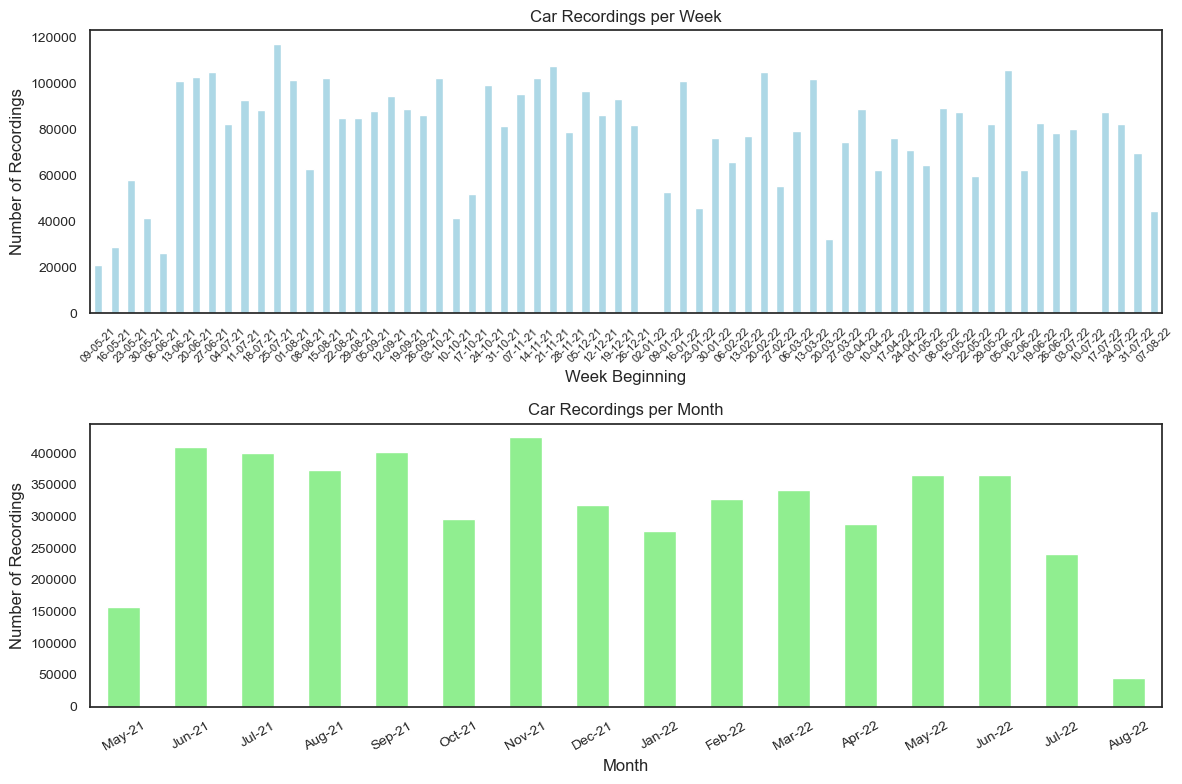

In [14]:
#Visualise recordings weekly and monthly
df['date'] = pd.to_datetime(df['date'])
weekly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'W')).size()
monthly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'ME')).size()

#Both in subplots
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # 2x1

# Weekly plot
weekly_counts.index = weekly_counts.index.strftime('%d-%m-%y')
weekly_counts.plot(ax=axes[0], kind='bar', color = 'lightblue')
axes[0].set_title('Car Recordings per Week')
axes[0].set_xlabel('Week Beginning')
axes[0].set_ylabel('Number of Recordings')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)

# Monthly plot
monthly_counts.index = monthly_counts.index.strftime('%b-%y')
monthly_counts.plot(ax=axes[1], kind='bar', color = 'lightgreen')
axes[1].set_title('Car Recordings per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Recordings')
axes[1].tick_params(axis='x', rotation=30, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

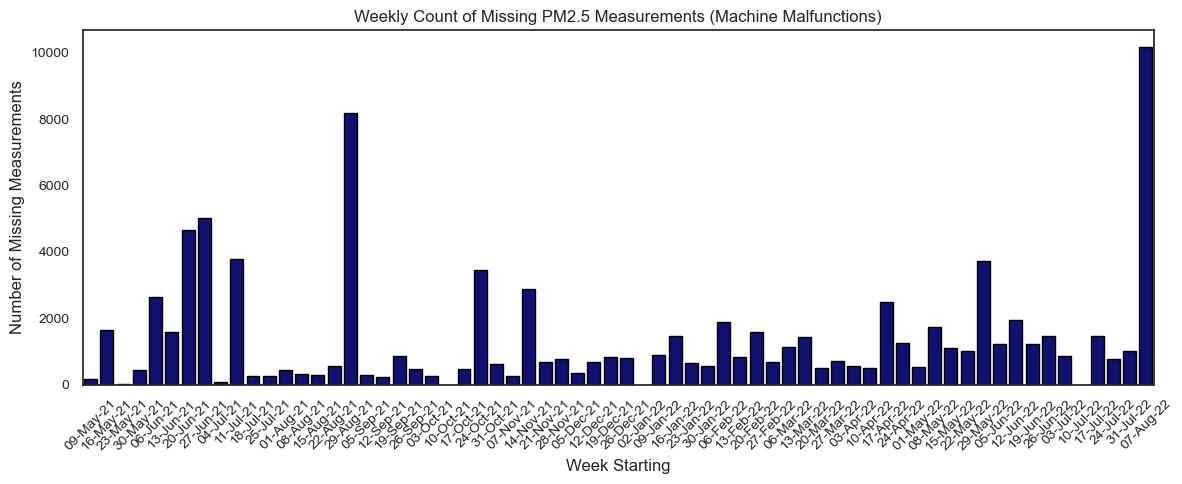

In [15]:
# Distribution of missing values

weekly_missing = df.groupby(pd.Grouper(key = 'timestamp', freq = 'W'))['PM25_ugm3'].apply(lambda x: x.isna().sum())
weekly_missing = weekly_missing.reset_index()
weekly_missing.columns = ['week_start', 'missing_count']
weekly_missing['week_label'] = weekly_missing['week_start'].dt.strftime('%d-%b-%y')

sns.set_theme(style='white')

# Plot
plt.figure(figsize=(12,5))
sns.barplot(x='week_label', y='missing_count', data=weekly_missing, color='navy', edgecolor='black')
plt.xlabel('Week Starting')
plt.ylabel('Number of Missing Measurements')
plt.title('Weekly Count of Missing PM2.5 Measurements (Machine Malfunctions)')

# Rotate x-axis
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

PM2.5 Recordings

In [16]:
# Number of unique measurements
num_unique = df['PM25_ugm3'].nunique(dropna=True)
print(f"Number of unique PM25_ugm3 measurements: {num_unique}")

#Range of Measurements
df['PM25_ugm3'].describe()
#from this can see that there are no negative recordings but some very large recordings way above mean and top quartile

Number of unique PM25_ugm3 measurements: 58495


count    4.940266e+06
mean     7.976111e+00
std      8.545271e+00
min      7.100000e-02
25%      3.574000e+00
50%      6.097000e+00
75%      1.012800e+01
max      1.960163e+03
Name: PM25_ugm3, dtype: float64

News articles remark expectionally high measures of PM2.5 of 400 in Rathmines in 2020, the highest measure since the 80s. There does not appear to be any news article reporting of any further anomaly events, suggesting that it is reasonable to assume any records beyond this level are machine errors. (https://www.breakingnews.ie/ireland/dublins-air-pollution-hits-highest-levels-since-the-1980s-1044551.html)

In [17]:
#Outliers
print(((df['PM25_ugm3'] > 400).sum()), "of the", ((df['PM25_ugm3'] > 0).sum()), 
      "readings are above 400ugm3, i.e. ", round(((df['PM25_ugm3'] > 400).mean() * 100),6), "%")

117 of the 4940266 readings are above 400ugm3, i.e.  0.002326 %


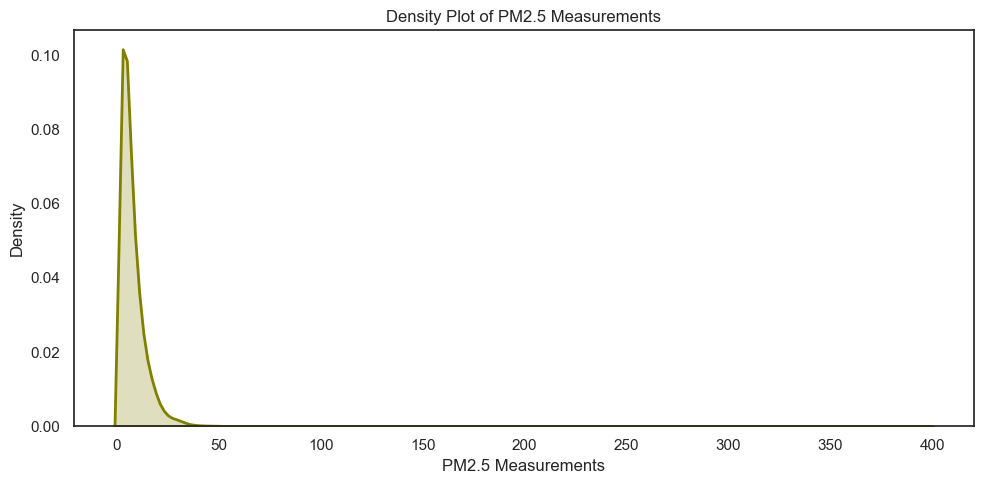

In [18]:
#Removing them
df_clean = df[df['PM25_ugm3'] <= 400].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

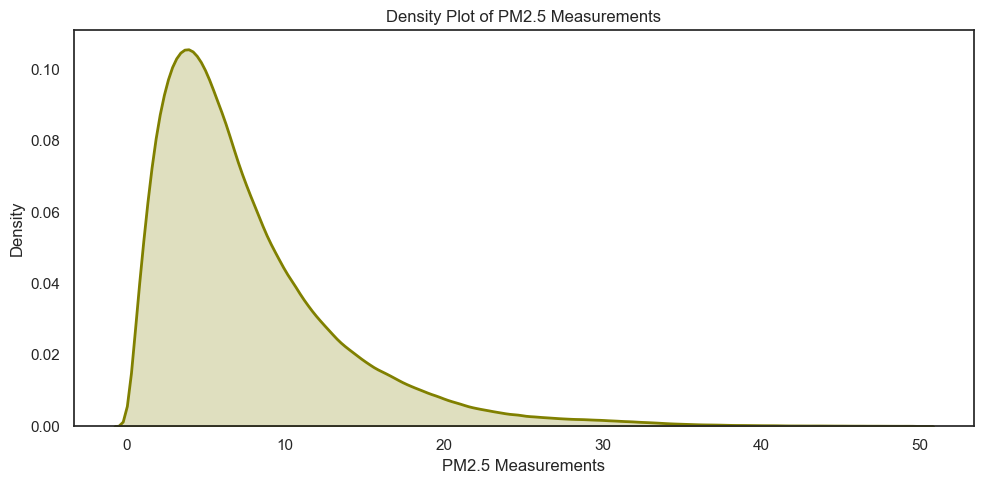

In [19]:
#Smaller density 
df_clean = df[df['PM25_ugm3'] <= 50].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

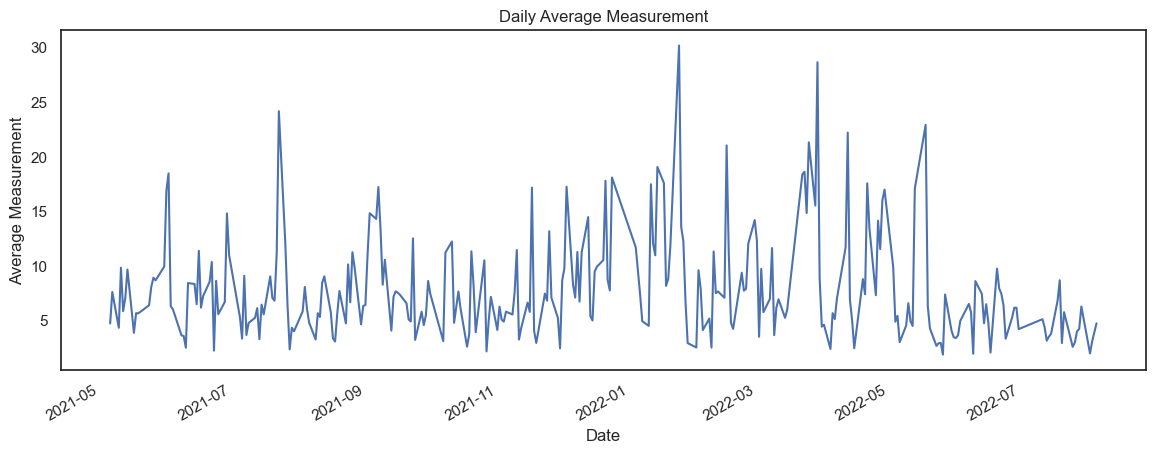

In [20]:
# Average measurement over time 
daily_avg = df_clean.groupby('date')['PM25_ugm3'].mean()
daily_avg.plot(figsize=(14,5))
plt.xlabel("Date")
plt.ylabel("Average Measurement")
plt.title("Daily Average Measurement")
plt.show()

In [21]:
# Heatmap hour
pivot = df_clean.pivot_table(
    values='PM25_ugm3',
    index='date',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Hour")
plt.ylabel("Date")
plt.title("Measurements by Date and Hour")
plt.show()

KeyError: 'hour'

Location

In [ ]:
#Approximate km^2 area car drove around
lat_min = df['latitude'].min()
lat_max = df['latitude'].max()
lon_min = df['longitude'].min()
lon_max = df['longitude'].max()

# Very rough conversion is 1 degree lat/long approxes to 111km
# Approximate conversion
lat_km = (lat_max - lat_min) * 111
mean_lat = df['latitude'].mean()
lon_km = (lon_max - lon_min) * 111 * math.cos(math.radians(mean_lat)) #times the cos(lat)

# Approximate area
area_km2 = lat_km * lon_km

print(f"Approximate area covered by car: {area_km2:.2f} km²")

In [ ]:
#lat/long by pm2.5

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='PM25_ugm3',       # color by recording
    palette='viridis',  # colormap palette
    data=df_clean,
    s=20               # size of points
)

plt.title("Latitude vs Longitude colored by Metric")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Weather data understanding

In [ ]:
# ==================================================
# 2.1 Weather data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load weather data
# -----------------------------
weather_path = Path().resolve().parent / "data" / "external" / "airport_weather.csv"

# The first 25 lines are metadata; the real header is on line 26
weather_df = pd.read_csv(weather_path, skiprows=25)

print("Weather data loaded.")
print(f"Shape: {weather_df.shape}")
display(weather_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(weather_df.columns.tolist())

print("\nData types:")
print(weather_df.dtypes)

print("\nDuplicate rows:")
print(weather_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("\nMissing dates after parsing:")
print(weather_df["date"].isna().sum())


# -----------------------------
# Keep only project-relevant dates:
# May 2021 to August 2022
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_filtered = weather_df[
    weather_df["date"].between(start_date, end_date)
].reset_index(drop=True)

print("\nFiltered to project-relevant period (May 2021 to August 2022).")
print(f"Shape: {weather_filtered.shape}")
display(weather_filtered.head())


# -----------------------------
# Remove unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]

existing_drop_cols = [col for col in cols_to_drop if col in weather_filtered.columns]
weather_filtered = weather_filtered.drop(columns=existing_drop_cols)

print("\nDropped unnecessary columns:")
print(existing_drop_cols)

print("\nRemaining columns:")
print(weather_filtered.columns.tolist())


# -----------------------------
# Coerce remaining non-date columns to numeric where possible
# -----------------------------
for col in weather_filtered.columns:
    if col != "date":
        weather_filtered[col] = pd.to_numeric(weather_filtered[col], errors="coerce")


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(weather_filtered.describe())

print("\nNon-numeric columns:")
non_numeric_cols = weather_filtered.select_dtypes(exclude="number").columns.tolist()
print(non_numeric_cols)


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {weather_filtered['date'].min()}")
print(f"End date:   {weather_filtered['date'].max()}")
print(f"Number of unique dates: {weather_filtered['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
date_dupes = weather_filtered.duplicated(subset=["date"]).sum()

print("\nGranularity check:")
print(f"Duplicate dates: {date_dupes}")

if date_dupes == 0:
    print("Granularity looks correct: one row per date.")
else:
    print("Warning: there are multiple rows for some dates.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    weather_filtered.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(weather_filtered))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Candidate weather predictors
# -----------------------------
candidate_weather_vars = [
    "rain", "maxtp", "mintp", "wdsp", "hm", "hg", "sun", "g_rad", "pe", "evap"
]

existing_weather_vars = [col for col in candidate_weather_vars if col in weather_filtered.columns]

print("\nCandidate weather variables summary:")
display(weather_filtered[existing_weather_vars].describe())

### 2.3 Traffic data understanding

In [ ]:
# ==================================================
# 2.2 Traffic data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load traffic data
# -----------------------------
traffic_path = Path().resolve().parent / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

traffic_df = pd.read_csv(traffic_path)

print("Traffic data loaded.")
print(f"Shape: {traffic_df.shape}")
display(traffic_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(traffic_df.columns.tolist())

print("\nData types:")
print(traffic_df.dtypes)

print("\nDuplicate rows:")
print(traffic_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("\nMissing dates after parsing:")
print(traffic_df["date"].isna().sum())


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(traffic_df.describe())

print("\nUnique regions:")
print(sorted(traffic_df["Region"].dropna().unique()))
print(f"Number of unique regions: {traffic_df['Region'].nunique()}")


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {traffic_df['date'].min()}")
print(f"End date:   {traffic_df['date'].max()}")
print(f"Number of unique dates: {traffic_df['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
region_day_dupes = traffic_df.duplicated(subset=["date", "Region"]).sum()

print("\nGranularity check:")
print(f"Duplicate date-region pairs: {region_day_dupes}")

if region_day_dupes == 0:
    print("Granularity looks correct: one row per day per region.")
else:
    print("Warning: there are multiple rows for some day-region pairs.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    traffic_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(traffic_df))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Quick understanding of key variables
# -----------------------------
key_vars = [
    "mean_daily_site_volume",
    "median_daily_site_volume",
    "total_daily_site_volume",
    "n_sites"
]

existing_key_vars = [col for col in key_vars if col in traffic_df.columns]

print("\nKey traffic variables summary:")
display(traffic_df[existing_key_vars].describe())


# -----------------------------
# Region-level coverage snapshot
# -----------------------------
region_summary = (
    traffic_df.groupby("Region", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        mean_traffic=("mean_daily_site_volume", "mean"),
        mean_sites=("n_sites", "mean")
    )
    .sort_values("Region")
)

print("\nRegion-level summary:")
display(region_summary)


## 3. Data aggregation & preparation

### 3.1 Aggregate mobile PM2.5 measurements to a Dublin-day target

In [ ]:
# ==================================================
# Air quality data: Step 2
# Aggregate mobile PM2.5 measurements to a Dublin-day target
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "raw" / "air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

print("\nRaw air quality data shape:")
print(air_df.shape)
display(air_df.head())


# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

print("\nShape after basic cleaning:")
print(air_df.shape)


# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date


# -----------------------------
# 4. Aggregate over location
# -----------------------------
# Decision:
# For each day, pool PM2.5 observations across all recorded Dublin locations
# and compute one Dublin-wide daily average PM2.5 value.

# Create an approximate location identifier for transparency
air_df["location_id"] = (
    air_df["latitude"].round(5).astype(str) + "_" +
    air_df["longitude"].round(5).astype(str)
)

air_daily = (
    air_df.groupby("date", as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max"),
        n_unique_locations=("location_id", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily.shape)

display(air_daily.head())


# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")

#### 3.1.1 By Location

In [ ]:
# ==================================================
# Air quality data: Step 2.1 (by location)
# Aggregate mobile PM2.5 measurements to Dublin location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date

# -----------------------------
# 4. Aggregate over location
        # North or South of Liffey
# -----------------------------
# Decision: Based on location being north or south of the Liffey River 

# Liffey latitude
liffey_lat = 53.346565

# Mask north and south locations
north_loc = air_df['latitude'] > liffey_lat
south_loc = air_df['latitude'] < liffey_lat

# Create series
location_label = pd.Series(index=air_df.index, dtype=str)

location_label[north_loc] = 'north'
location_label[south_loc] = 'south'

# Assign back to dataframe
air_df['location_label'] = location_label

# Group by date and location label
air_daily_loc = (
    air_df.groupby(["date", "location_label"], as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max")
    )
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily_loc.shape)

display(air_daily_loc.head())

# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily_loc.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")

### 3.2 Aggregate traffic measurements to a Dublin-day target

In [ ]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"
traffic_output_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("Raw traffic shape (region-day level):")
print(traffic_df.shape)
display(traffic_df.head())

# -----------------------------
# Aggregate from region-day to Dublin-day
# -----------------------------
# Decision:
# The PM2.5 target is a Dublin-wide daily average.
# To align traffic to that same spatial unit, aggregate region-level traffic
# to one Dublin-wide traffic summary per day.

traffic_dublin_daily = (
    traffic_df
    .groupby("date", as_index=False)
    .agg(
        dublin_daily_mean_site_traffic=("mean_daily_site_volume", "mean"),
        dublin_daily_median_site_traffic=("median_daily_site_volume", "mean"),
        dublin_daily_total_traffic=("total_daily_site_volume", "sum"),
        dublin_daily_n_sites=("n_sites", "sum"),
        dublin_daily_n_regions=("Region", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nTraffic shape after spatial aggregation to Dublin-day:")
print(traffic_dublin_daily.shape)
display(traffic_dublin_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data
# -----------------------------
traffic_output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_dublin_daily.to_csv(traffic_output_path, index=False)

print(f"\nSaved processed traffic data to:\n{traffic_output_path}")

#### 3.2.1 By location

In [ ]:
# ==================================================
# Traffic data (by location)
# Aggregate traffic patterns by location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

output_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

# -----------------------------
# Aggregate by NCITY and SCITY
# -----------------------------
n_s_city = (traffic_df['Region'] == 'NCITY') | (traffic_df['Region'] == 'SCITY')

traffic_location_daily = traffic_df[n_s_city].reset_index(drop=True)

traffic_location_daily = traffic_location_daily.rename(columns={'Region': 'location_label'})

traffic_location_daily['location_label'] = traffic_location_daily['location_label'].map({
    'NCITY': 'north',
    'SCITY': 'south'
})

print("\nTraffic shape after aggregation by location:")
print(traffic_location_daily.shape)
display(traffic_location_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data by location
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_location_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")

### 3.3 Preparing weather measurements

In [ ]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

weather_path = project_root / "data" / "external" / "airport_weather.csv"
weather_output_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"

# -----------------------------
# Load raw weather data
# -----------------------------
weather_df = pd.read_csv(weather_path, skiprows=25)

weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("Raw weather shape:")
print(weather_df.shape)
display(weather_df.head())

# -----------------------------
# Keep only project period
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_df = weather_df[weather_df["date"].between(start_date, end_date)].copy()

# -----------------------------
# Drop unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4",
    "ddhm", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]
existing_drop_cols = [col for col in cols_to_drop if col in weather_df.columns]
weather_df = weather_df.drop(columns=existing_drop_cols)

# -----------------------------
# Coerce non-date columns to numeric
# -----------------------------
for col in weather_df.columns:
    if col != "date":
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

# -----------------------------
# Keep one row per date
# -----------------------------
weather_daily = (
    weather_df
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nPrepared weather shape:")
print(weather_daily.shape)
display(weather_daily.head())

print("\nDuplicate dates:")
print(weather_daily.duplicated(subset=["date"]).sum())

# -----------------------------
# Save prepared weather data
# -----------------------------
weather_output_path.parent.mkdir(parents=True, exist_ok=True)
weather_daily.to_csv(weather_output_path, index=False)

print(f"\nSaved prepared weather data to:\n{weather_output_path}")

## 4. Data merging

### 4.1 Overall merge

In [ ]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

output_path = project_root / "data" / "processed" / "merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
air_df = pd.read_csv(air_path)
weather_daily = pd.read_csv(weather_path)
traffic_dublin_daily = pd.read_csv(traffic_path)

air_df["date"] = pd.to_datetime(air_df["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_dublin_daily["date"] = pd.to_datetime(traffic_dublin_daily["date"], errors="coerce")

print("Air quality shape:")
print(air_df.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_dublin_daily.shape)

# -----------------------------
# Merge datasets
# -----------------------------
merged_df = (
    air_df
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_dublin_daily, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_df["day_name"] = merged_df["date"].dt.day_name()
merged_df["day_of_week"] = merged_df["date"].dt.dayofweek
merged_df["is_weekend"] = merged_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "n_unique_locations",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_df.columns if col not in front_cols]
merged_df = merged_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

print("\nData types:")
print(merged_df.dtypes)

print("\nDuplicate dates:")
print(merged_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_df['date'].min()}")
print(f"End:   {merged_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_df.describe())

print("\nHead of merged dataset:")
display(merged_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

### 4.2 Merge by Location and Date

In [ ]:
# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

output_path = project_root / "data" / "processed" / "location_merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
weather_daily = pd.read_csv(weather_path)
air_daily_loc = pd.read_csv(air_path)
traffic_daily_loc = pd.read_csv(traffic_path)

# Standardize date
air_daily_loc["date"] = pd.to_datetime(air_daily_loc["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_daily_loc["date"] = pd.to_datetime(traffic_daily_loc["date"], errors="coerce")

print("Air quality shape:")
print(air_daily_loc.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_daily_loc.shape)

# -----------------------------
# Merge datasets
# -----------------------------
# Merging data with north and south city information
merged_location_df = (
    air_daily_loc
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_daily_loc, on=["date", "location_label"], how="left")
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_location_df["day_name"] = merged_location_df["date"].dt.day_name()
merged_location_df["day_of_week"] = merged_location_df["date"].dt.dayofweek
merged_location_df["is_weekend"] = merged_location_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "location_label",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_location_df.columns if col not in front_cols]
merged_location_df = merged_location_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_location_df.shape)

print("\nColumns:")
print(merged_location_df.columns.tolist())

print("\nData types:")
print(merged_location_df.dtypes)

print("\nDuplicate dates:")
print(merged_location_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_location_df['date'].min()}")
print(f"End:   {merged_location_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_location_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_location_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_location_df.describe())

print("\nHead of merged dataset:")
display(merged_location_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_location_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

## 5. Data limitations

### 5.1 All-Dublin

Weekends are structurally outside the Air View observational design, so continuity is assessed against an expected weekday-only sequence rather than the full calendar.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATA_DIR = Path('../data/processed')
ALL_DUBLIN_PATH = DATA_DIR / 'merged_daily_dublin_avg_pm25_weather_traffic.csv'
NORTH_SOUTH_PATH = DATA_DIR / 'location_merged_daily_dublin_avg_pm25_weather_traffic.csv'

all_dublin = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
north_south_raw = pd.read_csv(NORTH_SOUTH_PATH, parse_dates=['date'])
location_col = next(col for col in north_south_raw.columns if 'location' in col.lower() or 'label' in col.lower())
north_south = (
    north_south_raw.rename(columns={location_col: 'location_label'})
    .sort_values(['location_label', 'date'])
    .reset_index(drop=True)
)


def continuity_metrics(dates):
    dates = pd.Series(pd.to_datetime(dates)).drop_duplicates().sort_values()
    gaps = dates.diff().dt.days.dropna()
    span_days = (dates.max() - dates.min()).days + 1
    return {
        'start_date': dates.min().date(),
        'end_date': dates.max().date(),
        'observed_rows': int(len(dates)),
        'missing_calendar_days': int(span_days - len(dates)),
        'share_next_day_links': round((gaps == 1).mean(), 3) if len(gaps) else np.nan,
        'gaps_longer_than_1_day': int((gaps > 1).sum()),
        'max_gap_days': int(gaps.max()) if len(gaps) else 0,
    }


def weekday_continuity_diagnostics(dates):
    observed = pd.Series(pd.to_datetime(dates)).drop_duplicates().sort_values().reset_index(drop=True)
    expected_weekdays = pd.bdate_range(observed.min(), observed.max())
    unexpected_missing = expected_weekdays.difference(pd.DatetimeIndex(observed))

    gap_rows = []
    for i in range(1, len(observed)):
        prev_date = observed.iloc[i - 1]
        current_date = observed.iloc[i]
        expected_next = prev_date + pd.offsets.BDay(1)
        missing_weekdays_between = max(len(pd.bdate_range(prev_date, current_date)) - 2, 0)

        if current_date == expected_next:
            if prev_date.dayofweek == 4 and current_date.dayofweek == 0:
                gap_type = 'expected Monday-after-Friday gap'
            else:
                gap_type = 'expected next weekday'
        else:
            gap_type = 'unexpected longer weekday gap'

        gap_rows.append({
            'previous_date': prev_date.date(),
            'current_date': current_date.date(),
            'calendar_gap_days': int((current_date - prev_date).days),
            'missing_weekdays_between': missing_weekdays_between,
            'gap_type': gap_type,
        })

    gap_df = pd.DataFrame(gap_rows)
    gap_summary = (
        gap_df['gap_type']
        .value_counts(dropna=False)
        .rename_axis('gap_type')
        .reset_index(name='n_links')
    )

    missing_blocks = []
    if len(unexpected_missing) > 0:
        missing_series = pd.Series(unexpected_missing)
        block_id = missing_series.diff().dt.days.ne(1).cumsum()
        missing_blocks = (
            missing_series.groupby(block_id)
            .agg(block_start='min', block_end='max', n_missing_weekdays='size')
            .reset_index(drop=True)
        )
        missing_blocks['block_start'] = missing_blocks['block_start'].dt.date
        missing_blocks['block_end'] = missing_blocks['block_end'].dt.date

    summary = pd.DataFrame([
        {
            'observational_unit': 'one observed Dublin weekday',
            'weekday_coverage': ', '.join(sorted(observed.dt.day_name().unique())),
            'start_date': observed.min().date(),
            'end_date': observed.max().date(),
            'observed_rows': int(len(observed)),
            'expected_weekday_rows': int(len(expected_weekdays)),
            'unexpected_missing_weekdays': int(len(unexpected_missing)),
            'share_expected_weekday_links': round((gap_df['gap_type'] != 'unexpected longer weekday gap').mean(), 3),
            'weekday_gaps_longer_than_expected': int((gap_df['gap_type'] == 'unexpected longer weekday gap').sum()),
            'max_unexpected_weekday_gap': int(gap_df.loc[gap_df['gap_type'] == 'unexpected longer weekday gap', 'missing_weekdays_between'].max()) if (gap_df['gap_type'] == 'unexpected longer weekday gap').any() else 0,
        }
    ])

    return summary, gap_summary, gap_df, missing_blocks


def low_coverage_summary(df, target_col, coverage_cols, quantile=0.10):
    thresholds = {col: df[col].quantile(quantile) for col in coverage_cols if col in df.columns}
    flag = pd.Series(False, index=df.index)
    for col, threshold in thresholds.items():
        flag |= df[col] <= threshold

    summary = (
        df.assign(low_coverage=flag)
        .groupby('low_coverage')[target_col]
        .agg(['count', 'mean', 'median', 'std'])
        .round(3)
        .reset_index()
    )
    summary['coverage_rule'] = ', '.join(f'{col}<={value:.1f}' for col, value in thresholds.items())
    return summary[['low_coverage', 'coverage_rule', 'count', 'mean', 'median', 'std']]


all_summary, all_gap_summary, all_gap_detail, all_missing_blocks = weekday_continuity_diagnostics(all_dublin['date'])
display(all_summary)
display(all_gap_summary)
if len(all_missing_blocks) > 0:
    display(all_missing_blocks.head(8))


Once weekends are treated as expected non-observation days, continuity looks good: most observed transitions follow the weekday schedule, and the remaining breaks come from 41 unexpected missing weekdays spread across a limited number of gaps rather than from systematic weekend absence.

Inspect the PM2.5 target and whether lower-coverage days appear to distort the daily mean.

In [ ]:
display(
    all_dublin['dublin_daily_avg_pm25']
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(3)
    .to_frame(name='dublin_daily_avg_pm25')
)

display(
    low_coverage_summary(
        all_dublin,
        target_col='dublin_daily_avg_pm25',
        coverage_cols=['pm25_count', 'n_unique_locations'],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(all_dublin, x='dublin_daily_avg_pm25', bins=25, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('All-Dublin PM2.5 distribution')
axes[0].set_xlabel('Daily average PM2.5')

scatter = axes[1].scatter(
    all_dublin['pm25_count'],
    all_dublin['dublin_daily_avg_pm25'],
    c=all_dublin['n_unique_locations'],
    cmap='viridis',
    alpha=0.8,
)
axes[1].set_title('Target against daily PM2.5 coverage')
axes[1].set_xlabel('pm25_count')
axes[1].set_ylabel('Daily average PM2.5')
fig.colorbar(scatter, ax=axes[1], label='n_unique_locations')

plt.tight_layout()
plt.show()


The target remains suitable for regression: it is continuous, positive, and only moderately right-skewed. Coverage varies substantially across days, but low-coverage days do not show a clear mechanical break in the target, which supports keeping the all-Dublin series as the main modelling dataset.

**Takeaway.** The all-Dublin merged file is usable and reasonably stable after cleaning. Once weekends are treated as structurally out of scope, the data is fairly continuous, although the series still contains some unexpected missing weekdays and occasional low-coverage days.

### 5.2 North/South Dublin

As with the all-Dublin series, weekends are treated as structurally out of scope here, so continuity is assessed against an expected weekday-only sequence within each location subset.

In [ ]:
location_continuity_rows = []
location_gap_rows = []
location_missing_rows = []

for label, subset in north_south.groupby('location_label'):
    summary, gap_summary, _, missing_blocks = weekday_continuity_diagnostics(subset['date'])
    summary.insert(0, 'location_label', label)
    gap_summary.insert(0, 'location_label', label)

    location_continuity_rows.append(summary)
    location_gap_rows.append(gap_summary)

    if len(missing_blocks) > 0:
        location_missing_rows.append(
            missing_blocks.assign(location_label=label)
            .sort_values('n_missing_weekdays', ascending=False)
            .head(4)
        )

location_continuity = pd.concat(location_continuity_rows, ignore_index=True)
location_gap_summary = (
    pd.concat(location_gap_rows, ignore_index=True)
    .pivot(index='location_label', columns='gap_type', values='n_links')
    .fillna(0)
    .astype(int)
    .reset_index()
)

display(location_continuity)
display(location_gap_summary)

if location_missing_rows:
    display(pd.concat(location_missing_rows, ignore_index=True))


Once weekends are excluded from the expected sequence, South looks close to the all-Dublin continuity profile, whereas North still shows substantially more unexpected missing weekdays and weaker weekday-to-weekday continuity.

Compare the target distribution and coverage profile by location to judge whether both subsets are credible enough for a lightweight robustness check.

In [ ]:
location_target_summary = (
    north_south.groupby('location_label')['dublin_daily_avg_pm25']
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(3)
)
display(location_target_summary)

location_coverage_summary = pd.concat(
    [
        low_coverage_summary(group, 'dublin_daily_avg_pm25', ['pm25_count']).assign(location_label=label)
        for label, group in north_south.groupby('location_label')
    ],
    ignore_index=True,
)
display(location_coverage_summary[['location_label', 'low_coverage', 'coverage_rule', 'count', 'mean', 'median', 'std']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=north_south, x='location_label', y='dublin_daily_avg_pm25', ax=axes[0])
axes[0].set_title('PM2.5 by location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Daily average PM2.5')

sns.scatterplot(
    data=north_south,
    x='pm25_count',
    y='dublin_daily_avg_pm25',
    hue='location_label',
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Target against coverage by location')
axes[1].set_xlabel('pm25_count')
axes[1].set_ylabel('Daily average PM2.5')

plt.tight_layout()
plt.show()


North and South remain broadly comparable in PM2.5 levels, so the split does not create a fundamentally different target. The practical limitation is instead sample thickness: North has fewer observed days and more sparse-coverage days

**Takeaway.** South is fairly well aligned with the all-Dublin weekday regime, while North is still visibly thinner and should be interpreted more cautiously. Overall, should still be adequate for our purposes (robustness check).

## 6. Temporal features

### 6.1 Temporal dependence audit

This section audits temporal dependence in the observed all-Dublin weekday series only

In [29]:
from pathlib import Path

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ALL_DUBLIN_PATH = Path('../data/processed/merged_daily_dublin_avg_pm25_weather_traffic.csv')
target_col = 'dublin_daily_avg_pm25'

if 'all_dublin' not in globals():
    all_dublin = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date'])

all_dublin = all_dublin.sort_values('date').reset_index(drop=True).copy()


View the target over time to see whether a short-memory structure looks plausible.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_dublin['date'], all_dublin[target_col], color='#264653', linewidth=1.4)
ax.set_title('All-Dublin PM2.5 over observed weekdays')
ax.set_xlabel('Date')
ax.set_ylabel('Daily average PM2.5')
plt.tight_layout()
plt.show()


The series shows short-run persistence with occasional spikes, but not a slow-moving long-memory pattern. A short lag structure looks more defensible than a large set of distant lags.

Check whether weekday effects look strong enough to keep as a simple calendar feature.

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=all_dublin, x='day_name', y=target_col, order=weekday_order, ax=axes[0])
axes[0].set_title('PM2.5 by weekday')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Daily average PM2.5')

weekday_summary = (
    all_dublin.groupby('day_name')[target_col]
    .agg(mean='mean', median='median', count='count')
    .reindex(weekday_order)
    .round(3)
)
display(weekday_summary)

sns.pointplot(
    data=all_dublin,
    x='day_name',
    y=target_col,
    order=weekday_order,
    errorbar=None,
    ax=axes[1],
    color='#2a9d8f',
)
axes[1].set_title('Average PM2.5 by weekday')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Daily average PM2.5')

plt.tight_layout()
plt.show()


ACF shows how strongly the PM2.5 series is correlated with its own previous observed values at different lags, while PACF isolates the additional contribution of each lag after accounting for the shorter lags before it.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(all_dublin[target_col], lags=10, ax=axes[0])
axes[0].set_title('ACF of observed weekday PM2.5')
axes[0].set_xlabel('Observed lag')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(all_dublin[target_col], lags=10, ax=axes[1], method='ywm')
axes[1].set_title('PACF of observed weekday PM2.5')
axes[1].set_xlabel('Observed lag')
axes[1].set_ylabel('Partial autocorrelation')

plt.tight_layout()
plt.show()


The dependence appears front-loaded: lag 1 is the clearest signal, with much weaker incremental structure after the first few observed lags. That supports a short lag design such as `lag_1` to `lag_3`

Visualise `lag_1` to `lag_3` relationships to gain more evidence to determine ideal lag

In [ ]:
lag_check = all_dublin[['date', target_col]].copy()
for lag in [1, 2, 3]:
    lag_check[f'lag_{lag}'] = lag_check[target_col].shift(lag)

lag_corr = pd.DataFrame({
    'lag': [1, 2, 3],
    'correlation_with_target': [
        round(lag_check[target_col].corr(lag_check[f'lag_{lag}']), 3)
        for lag in [1, 2, 3]
    ],
})
display(lag_corr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lag in zip(axes, [1, 2, 3]):
    sns.regplot(
        data=lag_check,
        x=f'lag_{lag}',
        y=target_col,
        scatter_kws={'alpha': 0.65, 's': 28},
        line_kws={'color': '#e76f51'},
        ax=ax,
    )
    ax.set_title(f'Target vs lag_{lag}')
    ax.set_xlabel(f'lag_{lag}')
    ax.set_ylabel('PM2.5' if lag == 1 else '')

plt.tight_layout()
plt.show()


The direct lag checks tell the same story: `lag_1` carries the strongest information, `lag_2` still contributes some signal, and `lag_3` is weaker but still plausible as the upper end of a compact recent-history set.

#### Conclusion
The temporal diagnostics support keeping a short lag structure only. `lag_1` is the strongest and most defensible persistence feature, while `lag_2` and `lag_3` are still plausible as a compact recent-history extension; more distant lags do not look necessary at this stage. Weekday differences are visible but modest, so they are best handled with the existing `day_of_week` indicator rather than with more elaborate calendar features.

### 6.2 Temporal feature construction

Create the temporal features in a notebook dataframe so the original merged CSV remains unchanged

In [30]:
all_dublin_temporal = all_dublin.copy()

for lag in [1, 2, 3]:
    all_dublin_temporal[f'lag_{lag}'] = all_dublin_temporal[target_col].shift(lag)

temporal_feature_cols = ['day_of_week', 'lag_1', 'lag_2', 'lag_3']
model_df = all_dublin_temporal.copy()

display(model_df[['date', target_col] + temporal_feature_cols].head(8))


,date,dublin_daily_avg_pm25,day_of_week,lag_1,lag_2,lag_3
0,2021-05-06,4.903776,3,NaN,NaN,NaN
1,2021-05-07,8.028253,4,4.903776,NaN,NaN
2,2021-05-10,4.443267,0,8.028253,4.903776,NaN
3,2021-05-11,9.881657,1,4.443267,8.028253,4.903776
4,2021-05-12,5.863840,2,9.881657,4.443267,8.028253
5,2021-05-13,7.057951,3,5.863840,9.881657,4.443267
6,2021-05-14,9.739638,4,7.057951,5.863840,9.881657
7,2021-05-17,3.897264,0,9.739638,7.057951,5.863840


N.B. the first three rows are expected to be incomplete because the lag features need prior observed weekdays.

In [31]:
all_dublin_temporal.head()

,date,day_name,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,...,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions,lag_1,lag_2,lag_3
0,2021-05-06,Thursday,3,0,4.903776,7518,5684,0.702,107.655,12.0,...,2.8,4.4,17149.593217,16134.928571,14458493,865,7,NaN,NaN,NaN
1,2021-05-07,Friday,4,0,8.028253,13206,7902,1.023,764.816,11.1,...,2.7,4.1,17920.225608,17037.785714,15133373,866,7,4.903776,NaN,NaN
2,2021-05-10,Monday,0,0,4.443267,1566,1112,0.195,101.522,15.3,...,2.4,3.5,16803.592495,15754.428571,14089843,864,7,8.028253,4.903776,NaN
3,2021-05-11,Tuesday,1,0,9.881657,2964,1764,3.730,69.970,14.1,...,2.9,4.7,17419.522593,16005.642857,14678272,866,7,4.443267,8.028253,4.903776
4,2021-05-12,Wednesday,2,0,5.863840,650,522,0.596,31.540,12.3,...,1.9,2.8,17497.224895,16398.214286,14770830,865,7,9.881657,4.443267,8.028253


## 7. Exogenous predictor selection
-> layer upon `model_df` from previous section.

### 7.1 Correlation martrix TRAFFIC

This section explores the relationship between the traffic features and the target to inform feature selection. 

In [157]:
DATA_DIR = Path('../data/processed')
ALL_DUBLIN_PATH = DATA_DIR / 'merged_daily_dublin_avg_pm25_weather_traffic.csv'

df = pd.read_csv(ALL_DUBLIN_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)

In [158]:
# Correlation Matrix of the Traffic Features
cols = ['dublin_daily_mean_site_traffic',
       'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic', 'dublin_daily_avg_pm25']

# Compute correlation matrix
corr = df[cols].corr()

corr

,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_avg_pm25
dublin_daily_mean_site_traffic,1.000000,0.968963,0.786742,-0.046062
dublin_daily_median_site_traffic,0.968963,1.000000,0.723199,-0.022471
dublin_daily_total_traffic,0.786742,0.723199,1.000000,0.001022
dublin_daily_avg_pm25,-0.046062,-0.022471,0.001022,1.000000


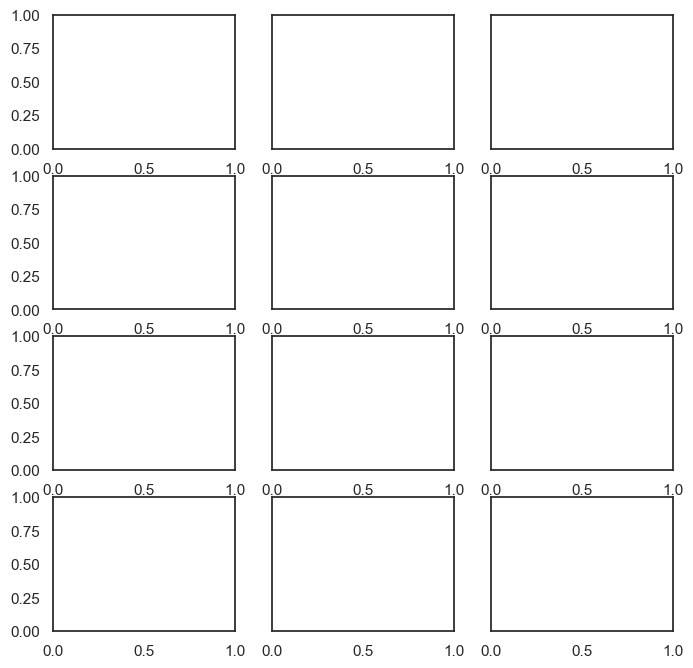

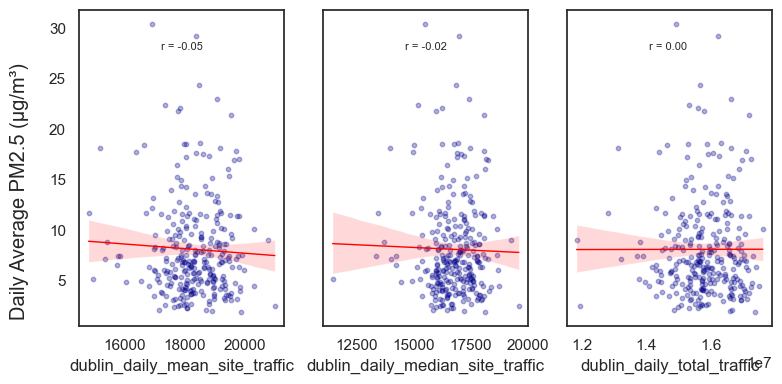

In [159]:
# Scatter plots grid of the traffic levels features and dublin_daily_avg_pm25

fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey = True)
cols = ['dublin_daily_mean_site_traffic',
       'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic']

for ax, col in zip(axes.flat, cols):
    sns.regplot(
        data=df,
        x=col,
        y="dublin_daily_avg_pm25",
        ax=ax,
        scatter_kws={"s": 10, "color": "darkblue", "alpha": 0.3},    #t
        line_kws={"color": "red", "linewidth": 1}
    )
    ax.set_title("")
    ax.set_ylabel("")

    r = df[[col, "dublin_daily_avg_pm25"]].corr().iloc[0, 1]
    ax.text(
        0.4, 0.9,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top'
      )

fig.supylabel("Daily Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

We can observe similar distribution of points in the scatter plots for the mean, median and total traffic measures. Daily median site traffic has slightly less spread of points than the mean. 

### 7.2 Correlation martrix WEATHER

This section explores the relationship between the weather features, and with the target to inform feature selection. 

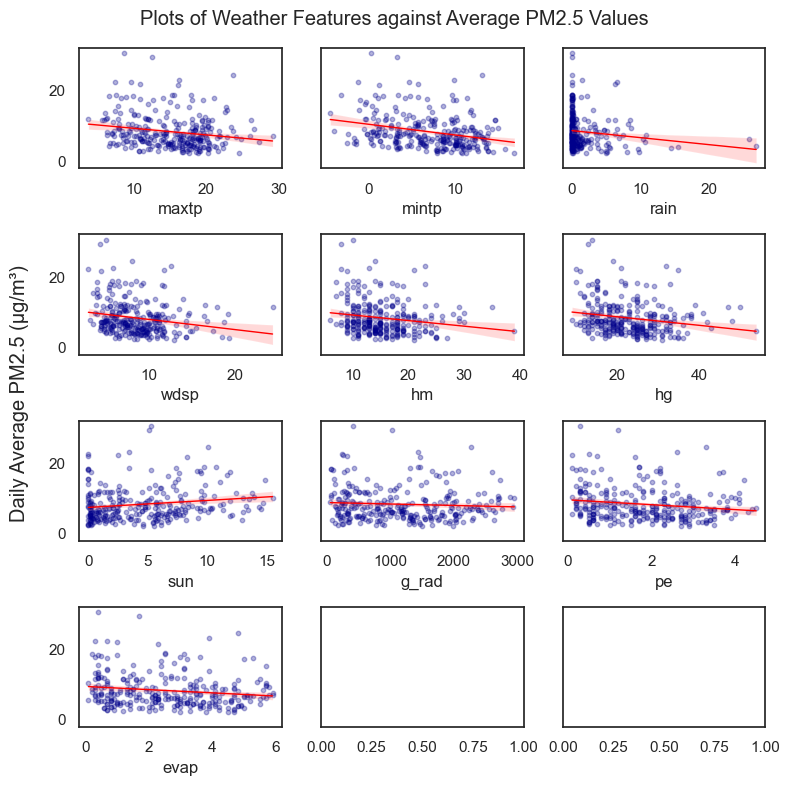

In [160]:
# Plots of weather features against dublin_daily_avg_pm25
fig, axes = plt.subplots(4, 3, figsize=(8, 8), sharey = True)

cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap'] #weather cols

for ax, col in zip(axes.flat, cols):
    sns.regplot(
        data=df,
        x=col,
        y="dublin_daily_avg_pm25",
        ax=ax,
        scatter_kws={"s": 10, "color": "darkblue", "alpha": 0.3},    #t
        line_kws={"color": "red", "linewidth": 1}
    )
    ax.set_title("")
    ax.set_ylabel("")

fig.supylabel("Daily Average PM2.5 (µg/m³)") #super i.e for all
fig.suptitle("Plots of Weather Features against Average PM2.5 Values")
fig.subplots_adjust(hspace=0.4) 
plt.tight_layout()

plt.show(), 


We observe differences each feature has with the target, in particular how condensed rain is along the x-axis. Additionally we see that many of the weather features has a similar slight negative trend with the target, e.g. max temp and min temp where including both may be redundant. Sun is the only feature which has a positive association with the daily PM2.5 measure.

In [155]:
# Correlation Heatmap of the Weather Features
cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap']

# Compute correlation matrix
corr = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Weather Feature Correlation Heatmap")
plt.show()

KeyError: "None of [Index(['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe',\n       'evap'],\n      dtype='object')] are in the [columns]"

In [ ]:
# Scatter plot of matrix of weather features
cols = ['maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap'] #all weather measurements

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
for i in range(10):
    for j in range(10):
        ax = axes[i, j]

        if i > j:  # lower triangle
            x = df[cols[j]]
            y = df[cols[i]]

            ax.scatter(x, y, s=10, alpha=0.3, color='blue') #points

            r = x.corr(y) #correltaion
            ax.text(0.5, 0.95, f"r={r:.2f}", transform=ax.transAxes,
                    ha='center', va='top', fontsize=5, fontweight='bold')

        else:
            ax.axis('off')  # hide upper triangle & diagonal

        if j == 0 and i > 0:
            ax.set_ylabel(cols[i], fontsize=9)
        else:
            ax.set_yticklabels([])

        if i == 9 and j < 9:
            ax.set_xlabel(cols[j], fontsize=9, rotation=45)
        else:
            ax.set_xticklabels([])
            
fig.suptitle("Pairplot of Weather Features")
plt.tight_layout()
plt.show()

The above correlation heatmap and pairs plot highlight how many of the weather features are highly correlated. `pe` and `evap` for instance are exceptionally highly correlated and would likely be redundant and add little value to the model as it does not help the model gain new information.

## 8. Baseline model (t-1)

### 8.1 Baseline historical average model
For the baseline model I chose to forecast based on an average model. This took the average of the last 4 values of that weekday and used it as the prediction for all of those future weekdays. I used business days as the frequency to account for the fact that there is only weekday data and no weekends.

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection import backtesting_forecaster
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from pandas.tseries.offsets import BusinessDay
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

In [119]:
# load dataset
ALL_DUBLIN_PATH = Path('../data/processed/merged_daily_dublin_avg_pm25_weather_traffic.csv')

all_dublin = pd.read_csv(ALL_DUBLIN_PATH)

# create time series object where datetime is the index
all_dublin_ts = all_dublin.set_index('date')
all_dublin_ts.index = pd.to_datetime(all_dublin_ts.index)

In [120]:
# train-test split
# where is 80% in the dataframe
eighty_pct = int(len(all_dublin_ts) * .8)

data_train = all_dublin_ts[:eighty_pct].asfreq('B').ffill() # uses business days as frequency
data_test  = all_dublin_ts[eighty_pct:].asfreq('B').ffill()

y_train = data_train['dublin_daily_avg_pm25']
y_test  = data_test['dublin_daily_avg_pm25']

print(f" Train values: {data_train.index.min()} --- {data_train.index.max()} n={len(data_train)}")
print(f" Test values: {data_test.index.min()} --- {data_test.index.max()} n={len(data_test)}")

 Train values: 2021-05-06 00:00:00 --- 2022-04-28 00:00:00 n=256
 Test values: 2022-04-29 00:00:00 --- 2022-08-05 00:00:00 n=71


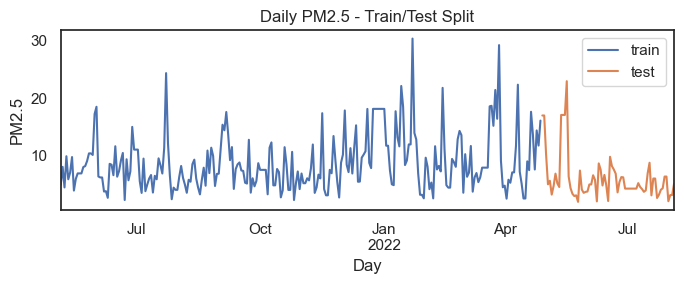

In [132]:
# Plot train-test split
fig, ax = plt.subplots(figsize=(7, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
ax.set_title('Daily PM2.5 - Train/Test Split')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

In [128]:
# fit forecaster
forecaster = ForecasterEquivalentDate(
    offset = pd.DateOffset(weeks=1), 
    n_offsets = 4, # average of last 4 equivalent weekdays
    agg_func = np.mean) # use the mean

forecaster.fit(y=y_train)
forecaster

======================== 
ForecasterEquivalentDate 
======================== 
Offset: <DateOffset: weeks=1> 
Number of offsets: 4 
Aggregation function: mean 
Window size: 20 
Series name: dublin_daily_avg_pm25 
Training range: [Timestamp('2021-05-06 00:00:00'), Timestamp('2022-04-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <BusinessDay> 
Creation date: 2026-03-24 17:07:53 
Last fit date: 2026-03-24 17:07:53 
Skforecast version: 0.21.0 
Python version: 3.13.5 
Forecaster id: None

In [129]:
# make predictions
predictions = forecaster.predict(steps=len(y_test)) # predicts for the number of values in test set
predictions.head(20)

2022-04-29     6.988515
2022-05-02     6.067794
2022-05-03    12.875271
2022-05-04     7.911883
2022-05-05    11.474027
2022-05-06     6.988515
2022-05-09     6.067794
2022-05-10    12.875271
2022-05-11     7.911883
2022-05-12    11.474027
2022-05-13     6.988515
2022-05-16     6.067794
2022-05-17    12.875271
2022-05-18     7.911883
2022-05-19    11.474027
2022-05-20     6.988515
2022-05-23     6.067794
2022-05-24    12.875271
2022-05-25     7.911883
2022-05-26    11.474027
Freq: B, Name: pred, dtype: float64

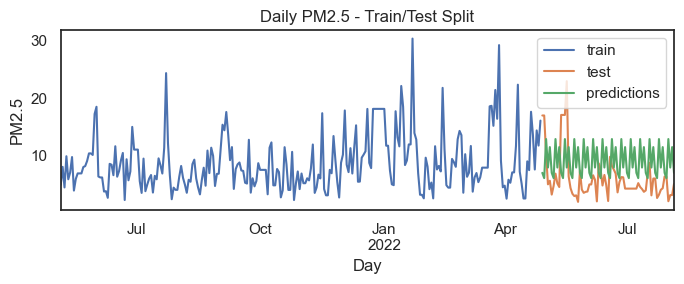

In [133]:
# plot predictions
fig, ax = plt.subplots(figsize=(7, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
predictions.plot(ax=ax, label = 'predictions')
ax.set_title('Daily PM2.5 - Train/Test Split')
ax.legend()
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

In [136]:
# assess using MSE and RMSE
mse = mean_squared_error(
    y_true = y_test,
    y_pred = predictions
)
print(f" Mean Squared Error: {mse}")

rmse = sqrt(mse)
print(f" Root Mean Sqaured Error: {rmse}")

 Mean Squared Error: 35.07413876222187
 Root Mean Sqaured Error: 5.922342337472722


### 8.1.1 For curiosities sake

In [139]:
## Function to create a sliding window
def get_window(df, window_size, window_columns, other_columns):

    X = []
    for i in range(len(df) - window_size):
        window = []

        # Collect data for each column in the specified window
        for col in window_columns:
            window.extend(df[col].iloc[i:i+window_size].values)

        # Add the other columns only once (for the current day) - non time series features for day you are trying to predict
        # things you already know about the day you are predicting
        for col in other_columns:
            window.append(df[col].iloc[i])
        X.append(window)

    return np.array(X)

In [161]:
# Create windows for each column
window_size = 2 # Use the previous 3 days of data
window_params = ['dublin_daily_avg_pm25','sun', 'wdsp'] # use the pm25, sun, wind speed
other_params = ['day_of_week'] # we know what day of the week it will be
output_param = ['dublin_daily_avg_pm25'] # predict the temperature

X = get_window(all_dublin, window_size, window_params, other_params)
y = all_dublin[output_param][window_size:].values

# Check they are the same length
print(X.shape, len(y))

## How many parameters do we have as input?
print(len(X[0]))

(284, 7) 284
7


In [162]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) ## do not set shuffle to True

In [163]:
## Use some regression models (eg LinearRegression(), RandomForestRegressor())

## fit the model using X_train, y_train

# linear regression
model = LinearRegression()

# fit model
model.fit(X_train, y_train)

# Make predictions for X_test
y_pred = model.predict(X_test)

# Evaluate performance of the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f" MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

 MAE: 3.3214287136554095, MSE: 16.119388164600096, RMSE: 4.014895785023579


[[ 0.03034823  0.32507992  0.06621585  0.14685614  0.16249767 -0.19126134
   0.19926747]]


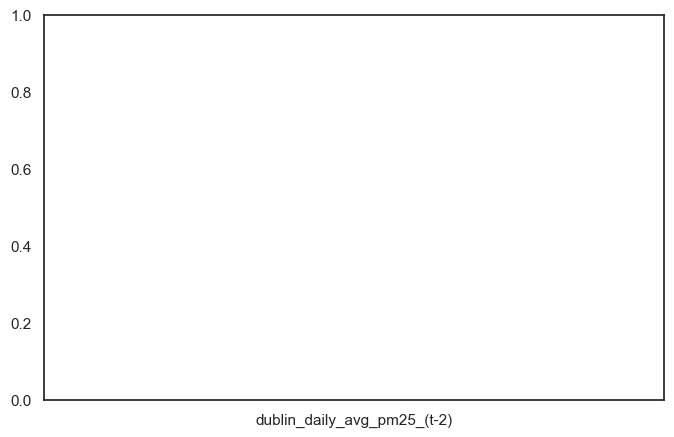

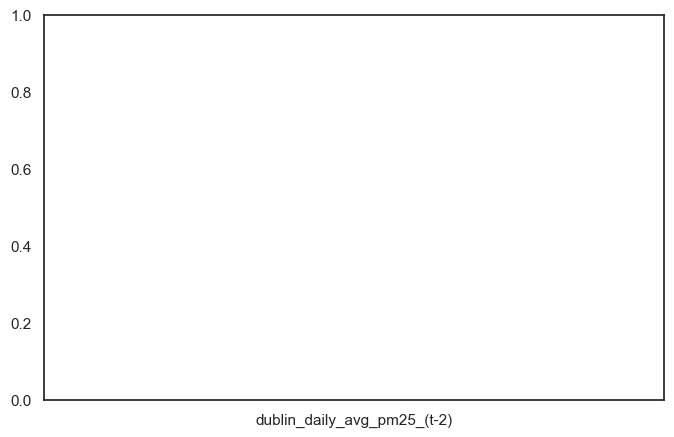

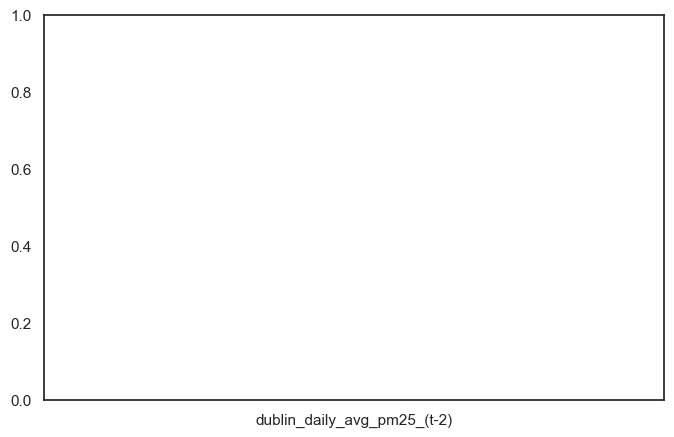

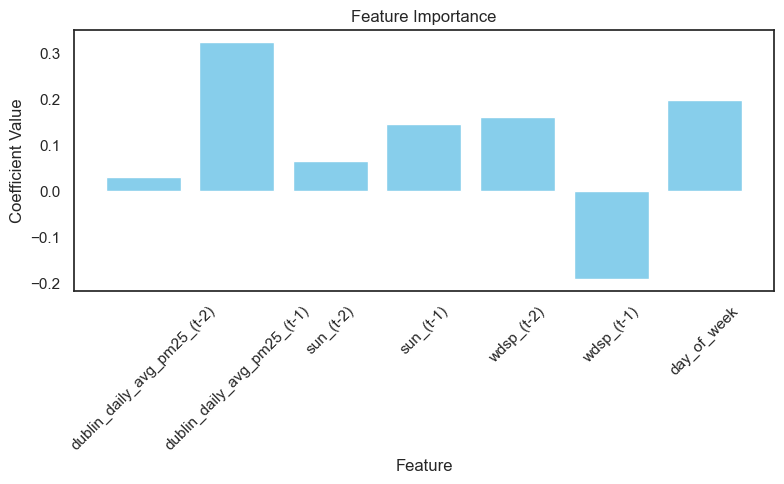

In [171]:
## get the model coefficients
print(model.coef_)
model_coeffs = model.coef_
model_coeffs = model_coeffs.flatten() # flatten to 1D
feature_names = [f'{param}_(t-{window_size - i})' for param in window_params for i in range(window_size)]+other_params


# Create a bar chart for the feature importance
plt.figure(figsize=(8, 5))
plt.bar(feature_names, model_coeffs, color='skyblue')

# Add titles and labels
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.tight_layout()
plt.show()

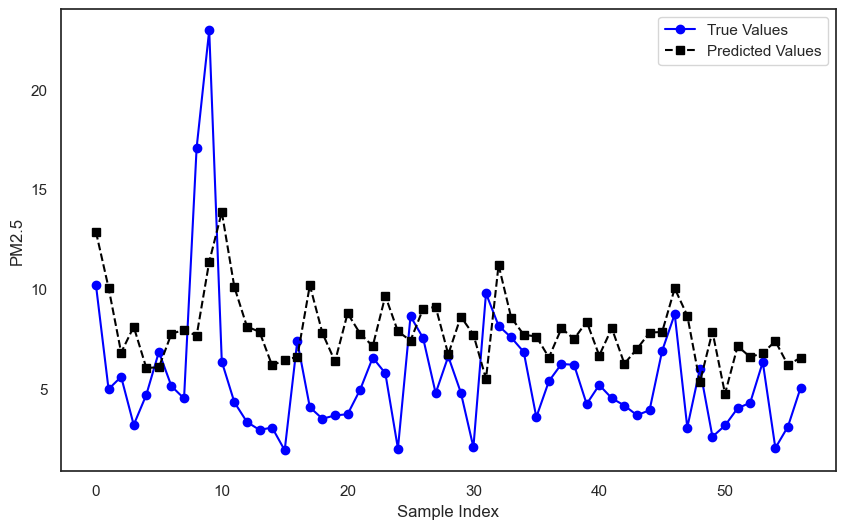

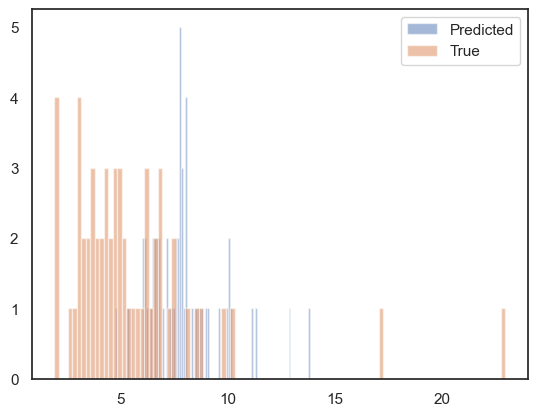

In [172]:
# Create a plot to compare the true values and the predicted values
plt.figure(figsize=(10, 6))

# Plot true values (actual values from y_test)
plt.plot(y_test[:100], label='True Values', color='blue', linestyle='-', marker='o')

# Plot predicted values (from the model)
plt.plot(y_pred[:100], label='Predicted Values', color='black', linestyle='--', marker='s')

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('PM2.5')

#plt.ylabel('Daily Rainfall (mm)')
plt.legend()

# Show the plot
plt.show()

plt.hist(y_pred,100, alpha = 0.5, label = 'Predicted')
plt.hist(y_test, 100, alpha = 0.5, label = 'True')
plt.legend()
plt.show()

## 9. Forecasting models

## 10. Inter-model evaluation